# Camera A heat-impulse: independent FITS cross-correlation check

This notebook reproduces the independent seed-centred phase-correlation check requested for the three Camera A frames:

- `cameraA_frame_0001_baseline.fits`
- `cameraA_frame_0024_pulse_midpoint.fits`
- `cameraA_frame_0055_max_response.fits`

It measures the apparent image displacement of the pulse-midpoint and maximum-response frames relative to the baseline frame. It is a **three-frame validation check**, not a replacement for the complete time-series analysis.

**Sign convention:** positive `observed_dx_px` means the target feature moved right in FITS x; positive `observed_dy_px` means it moved upward in FITS y. The notebook verifies this convention with a sub-pixel Fourier self-test before processing the data.


## 1. Install dependencies

Run this cell once in the same Jupyter environment. Restart the kernel afterwards only if Jupyter asks you to.

In [9]:
%pip install -q astropy scipy scikit-image pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Put the three FITS files in one folder and set its path

Download the three email attachments first. Update `DATA_DIR` below to the folder that contains them.

The seed defaults come from the independent Camera Mount A check supplied for this comparison. Do not change them unless the seed location was deliberately revised for Camera A.

In [18]:
from pathlib import Path

# CHANGE ONLY THIS PATH
DATA_DIR = Path(r"C:\Users\biswa\Heloo exoplanets")

BASELINE_FILE = DATA_DIR / "cameraA_frame_0001_baseline.fits"
TARGET_FILES = [
    DATA_DIR / "cameraA_frame_0024_pulse_midpoint.fits",
    DATA_DIR / "cameraA_frame_0055_max_response.fits",
]

# Independent Camera A peer-check settings
SEED_X = 3963.637
SEED_Y = 2981.505
ROI_SIZE = 160
UPSAMPLE = 100

OUTPUT_DIR = DATA_DIR / "cameraA_crosscorr_peercheck"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_files = [BASELINE_FILE, *TARGET_FILES]
missing = [str(path) for path in all_files if not path.exists()]

if missing:
    raise FileNotFoundError(
        "These FITS files were not found:\n- " + "\n- ".join(missing)
        + "\n\nCheck DATA_DIR and make sure the files are fully downloaded."
    )

print("Baseline:", BASELINE_FILE.name)
print("Targets:", [path.name for path in TARGET_FILES])
print("Output folder:", OUTPUT_DIR)

Baseline: cameraA_frame_0001_baseline.fits
Targets: ['cameraA_frame_0024_pulse_midpoint.fits', 'cameraA_frame_0055_max_response.fits']
Output folder: C:\Users\biswa\Heloo exoplanets\cameraA_crosscorr_peercheck


## 3. Imports and registration utilities

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.ndimage import gaussian_filter, shift as ndi_shift
from skimage.registration import phase_cross_correlation


def find_image_hdu(hdul: fits.HDUList):
    for hdu in hdul:
        if int(hdu.header.get("NAXIS", 0)) >= 2:
            return hdu
    raise RuntimeError("No two-dimensional FITS image HDU was found.")


def get_shape(path: Path) -> tuple[int, int]:
    with fits.open(
        path,
        mode="readonly",
        memmap=False,
        lazy_load_hdus=False,
        do_not_scale_image_data=False,
        ignore_missing_end=True,
    ) as hdul:
        hdu = find_image_hdu(hdul)
        nx = int(hdu.header.get("NAXIS1", 0))
        ny = int(hdu.header.get("NAXIS2", 0))

    if nx <= 0 or ny <= 0:
        raise RuntimeError(f"Invalid FITS image dimensions: {path}")

    return ny, nx


def seed_bounds(image_shape, seed_x, seed_y, roi_size):
    ny, nx = image_shape
    half = roi_size // 2

    x0 = int(np.rint(seed_x)) - half
    x1 = x0 + roi_size
    y0 = int(np.rint(seed_y)) - half
    y1 = y0 + roi_size

    if x0 < 0 or y0 < 0 or x1 > nx or y1 > ny:
        raise RuntimeError(
            f"ROI x={x0}:{x1}, y={y0}:{y1} does not fit image shape ({ny}, {nx})."
        )
    return x0, x1, y0, y1


def read_scaled_crop(path, bounds):
    x0, x1, y0, y1 = bounds

    with fits.open(
        path,
        mode="readonly",
        memmap=False,
        lazy_load_hdus=False,
        do_not_scale_image_data=False,
        ignore_missing_end=True,
    ) as hdul:
        image = np.asarray(find_image_hdu(hdul).data)
        while image.ndim > 2:
            image = image[0]
        crop = np.array(image[y0:y1, x0:x1], dtype=np.float32, copy=True)

    expected_shape = (y1 - y0, x1 - x0)
    if crop.shape != expected_shape:
        raise RuntimeError(f"Unexpected crop shape for {path}: {crop.shape}, expected {expected_shape}")

    return crop


def robust_standardise(image):
    image = np.asarray(image, dtype=np.float64)
    good = np.isfinite(image)

    if good.sum() < 100:
        raise RuntimeError("Registration ROI has too few finite pixels.")

    med = np.nanmedian(image[good])
    mad = np.nanmedian(np.abs(image[good] - med))
    scale = 1.4826 * mad

    if not np.isfinite(scale) or scale <= 0:
        scale = np.nanstd(image[good])
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0

    return (image - med) / scale


def prepare_crop(crop, roi_size):
    image = np.asarray(crop, dtype=np.float64)
    bad = ~np.isfinite(image)

    if bad.any():
        image = image.copy()
        fill = np.nanmedian(image[~bad])
        image[bad] = fill if np.isfinite(fill) else 0.0

    highpass = image - gaussian_filter(image, sigma=max(3.0, roi_size / 24.0))
    highpass = robust_standardise(highpass)
    highpass = np.clip(highpass, -8.0, 8.0)

    edge = max(4, roi_size // 20)
    highpass[:edge, :] = 0.0
    highpass[-edge:, :] = 0.0
    highpass[:, :edge] = 0.0
    highpass[:, -edge:] = 0.0

    return highpass * np.outer(np.hanning(highpass.shape[0]), np.hanning(highpass.shape[1]))


def ncc(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    good = np.isfinite(a) & np.isfinite(b)

    if good.sum() < 100:
        return float("nan")

    a = a[good] - np.mean(a[good])
    b = b[good] - np.mean(b[good])

    denom = np.sqrt(np.sum(a * a) * np.sum(b * b))
    return float(np.sum(a * b) / denom) if denom > 0 else float("nan")


def fourier_translate(image, dy, dx):
    ny, nx = image.shape
    fy = np.fft.fftfreq(ny)[:, None]
    fx = np.fft.fftfreq(nx)[None, :]
    phase = np.exp(-2j * np.pi * (fy * dy + fx * dx))
    return np.fft.ifft2(np.fft.fft2(image) * phase).real


def run_selftest(reference, upsample):
    expected_dx = 0.37
    expected_dy = -0.29
    moving = fourier_translate(reference, expected_dy, expected_dx)

    shift_yx, _, _ = phase_cross_correlation(
        reference,
        moving,
        upsample_factor=upsample,
        normalization=None,
    )

    recovered_dx = -float(shift_yx[1])
    recovered_dy = -float(shift_yx[0])
    error = float(np.hypot(recovered_dx - expected_dx, recovered_dy - expected_dy))

    return {
        "expected_dx_px": expected_dx,
        "expected_dy_px": expected_dy,
        "recovered_dx_px": recovered_dx,
        "recovered_dy_px": recovered_dy,
        "radial_error_px": error,
        "pass": error <= 0.02,
    }

## 4. Confirm the FITS geometry and inspect the selected ROI

This is the first quality-control checkpoint. The green cross should be close to the intended registration feature. Stop here and send a screenshot if it is obviously not centred on the feature.

Full FITS shape (y, x): (6388, 9576)
Seed (FITS x, y): (3963.637, 2981.505)
ROI bounds: x=3884:4044, y=2902:3062


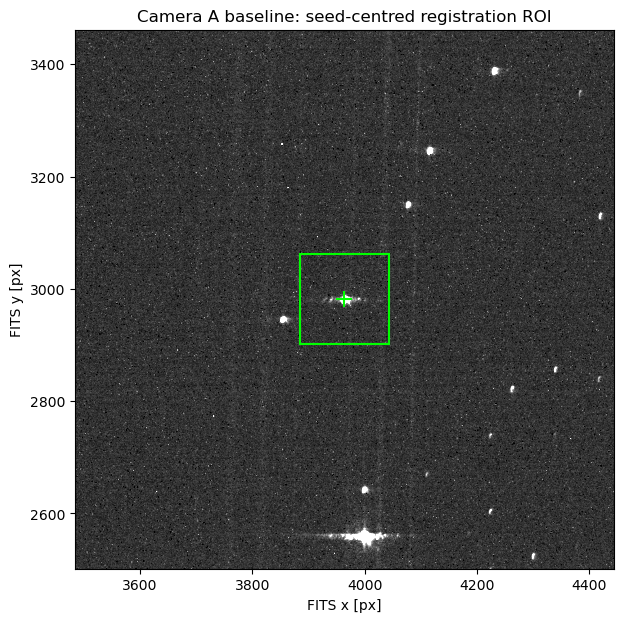

In [21]:
image_shape = get_shape(BASELINE_FILE)
bounds = seed_bounds(image_shape, SEED_X, SEED_Y, ROI_SIZE)
x0, x1, y0, y1 = bounds

print("Full FITS shape (y, x):", image_shape)
print(f"Seed (FITS x, y): ({SEED_X:.3f}, {SEED_Y:.3f})")
print(f"ROI bounds: x={x0}:{x1}, y={y0}:{y1}")

with fits.open(BASELINE_FILE, memmap=False, ignore_missing_end=True) as hdul:
    full_image = np.asarray(find_image_hdu(hdul).data)
    while full_image.ndim > 2:
        full_image = full_image[0]

fig, ax = plt.subplots(figsize=(7, 7))
vmin, vmax = np.nanpercentile(full_image, [2, 99.8])
ax.imshow(full_image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
ax.add_patch(plt.Rectangle((x0, y0), ROI_SIZE, ROI_SIZE, fill=False, edgecolor="lime", linewidth=1.5))
ax.plot(SEED_X, SEED_Y, marker="+", color="lime", markersize=12, markeredgewidth=1.5)
ax.set_xlim(SEED_X - 3 * ROI_SIZE, SEED_X + 3 * ROI_SIZE)
ax.set_ylim(SEED_Y - 3 * ROI_SIZE, SEED_Y + 3 * ROI_SIZE)
ax.set_title("Camera A baseline: seed-centred registration ROI")
ax.set_xlabel("FITS x [px]")
ax.set_ylabel("FITS y [px]")
plt.show()

## 5. Run the independent three-frame cross-correlation check

In [22]:
reference_raw = read_scaled_crop(BASELINE_FILE, bounds)
reference = prepare_crop(reference_raw, ROI_SIZE)

selftest = run_selftest(reference, UPSAMPLE)
print(
    "Fourier self-test:",
    "PASS" if selftest["pass"] else "CHECK",
    f"(radial error = {selftest['radial_error_px']:.4f} px)"
)

if not selftest["pass"]:
    raise RuntimeError("The registration self-test failed. Do not interpret FITS results yet.")

rows = []
plot_items = []

for path in TARGET_FILES:
    target_raw = read_scaled_crop(path, bounds)
    target = prepare_crop(target_raw, ROI_SIZE)

    # Shift that must be applied to target to align it with baseline.
    apply_y, apply_x = phase_cross_correlation(
        reference,
        target,
        upsample_factor=UPSAMPLE,
        normalization=None,
    )[0]
    apply_x = float(apply_x)
    apply_y = float(apply_y)

    # Physical / observed motion of the target image relative to baseline.
    observed_dx = -apply_x
    observed_dy = -apply_y

    aligned = ndi_shift(target, shift=(apply_y, apply_x), order=3, mode="nearest", prefilter=True)
    aligned_raw = ndi_shift(target_raw, shift=(apply_y, apply_x), order=3, mode="nearest", prefilter=True)

    before = ncc(reference, target)
    after = ncc(reference, aligned)

    rows.append({
        "target_file": path.name,
        "observed_dx_px": observed_dx,
        "observed_dy_px": observed_dy,
        "radial_shift_px": float(np.hypot(observed_dx, observed_dy)),
        "apply_dx_px": apply_x,
        "apply_dy_px": apply_y,
        "ncc_before": before,
        "ncc_after": after,
        "ncc_gain": after - before,
        "seed_x_px": SEED_X,
        "seed_y_px": SEED_Y,
        "roi_size_px": ROI_SIZE,
        "roi_x0": x0,
        "roi_x1": x1,
        "roi_y0": y0,
        "roi_y1": y1,
        "reference_frame_count": 1,
    })

    plot_items.append({
        "path": path,
        "target_raw": target_raw,
        "aligned_raw": aligned_raw,
        "apply_x": apply_x,
        "apply_y": apply_y,
        "ncc_gain": after - before,
    })

results = pd.DataFrame(rows)
results

Fourier self-test: PASS (radial error = 0.0000 px)


,target_file,observed_dx_px,observed_dy_px,radial_shift_px,apply_dx_px,apply_dy_px,ncc_before,ncc_after,ncc_gain,seed_x_px,seed_y_px,roi_size_px,roi_x0,roi_x1,roi_y0,roi_y1,reference_frame_count
0,cameraA_frame_0024_pulse_midpoint.fits,-0.36,0.12,0.379473,0.36,-0.12,0.888479,0.907765,0.019286,3963.637,2981.505,160,3884,4044,2902,3062,1
1,cameraA_frame_0055_max_response.fits,-1.25,0.27,1.278828,1.25,-0.27,0.264039,0.325246,0.061207,3963.637,2981.505,160,3884,4044,2902,3062,1


### How to read this table

- `observed_dx_px`, `observed_dy_px`: apparent shift of each target frame relative to the baseline.
- `radial_shift_px`: total magnitude of that apparent displacement.
- `ncc_gain`: correlation improvement after applying the measured translation. A positive and meaningful gain supports that the translation is real and that the registration is behaving coherently.
- `apply_dx_px`, `apply_dy_px`: the correction shift used only to align target to baseline; these values have the opposite sign of the observed motion.

For the heat-impulse validation, the midpoint and maximum-response frames should show a plausible progression in displacement. The full logged sequence remains necessary to establish temporal evolution, uncertainty, recovery, and the thermal interpretation.


## 6. Save the numerical results and create visual diagnostics

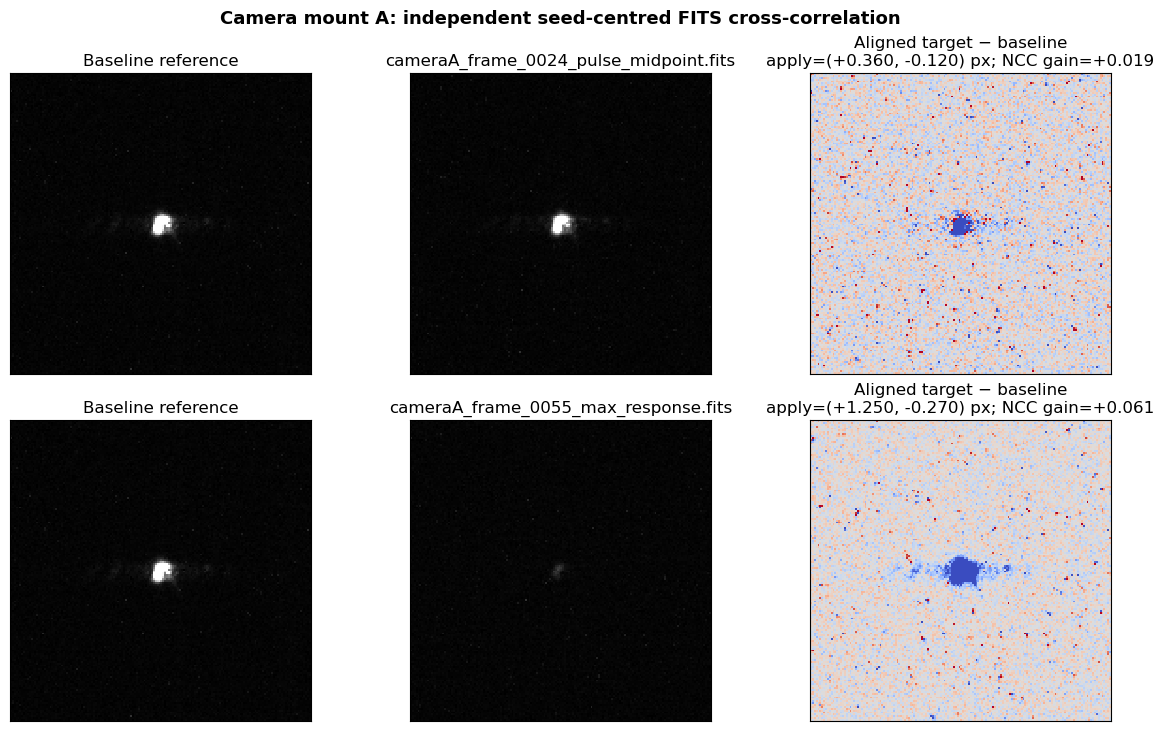

Saved CSV: C:\Users\biswa\Heloo exoplanets\cameraA_crosscorr_peercheck\cameraA_crosscorr_results.csv
Saved diagnostic PNG: C:\Users\biswa\Heloo exoplanets\cameraA_crosscorr_peercheck\cameraA_crosscorr_diagnostic.png


In [24]:
csv_path = OUTPUT_DIR / "cameraA_crosscorr_results.csv"
results.to_csv(csv_path, index=False)

nrows = len(plot_items)
fig, axes = plt.subplots(nrows, 3, figsize=(12, 3.6 * nrows), constrained_layout=True)

if nrows == 1:
    axes = np.array([axes])

vmin, vmax = np.nanpercentile(reference_raw, [2, 99.8])

for index, item in enumerate(plot_items):
    ax_ref, ax_target, ax_residual = axes[index]

    ax_ref.imshow(reference_raw, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_ref.set_title("Baseline reference")

    ax_target.imshow(item["target_raw"], origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_target.set_title(item["path"].name)

    residual = item["aligned_raw"] - reference_raw
    limit = np.nanpercentile(np.abs(residual), 99)
    limit = limit if np.isfinite(limit) and limit > 0 else 1.0

    ax_residual.imshow(
        residual,
        origin="lower",
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_residual.set_title(
        "Aligned target − baseline\n"
        f"apply=({item['apply_x']:+.3f}, {item['apply_y']:+.3f}) px; "
        f"NCC gain={item['ncc_gain']:+.3f}"
    )

    for ax in (ax_ref, ax_target, ax_residual):
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Camera mount A: independent seed-centred FITS cross-correlation", fontsize=13, fontweight="bold")

png_path = OUTPUT_DIR / "cameraA_crosscorr_diagnostic.png"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved CSV:", csv_path)
print("Saved diagnostic PNG:", png_path)

## 7. Compact result statement to send back

Run this only after checking the ROI and diagnostic figure. It creates a factual, concise message without over-claiming what three frames can establish.

In [25]:
for _, row in results.iterrows():
    print(
        f"{row['target_file']}: "
        f"Δx = {row['observed_dx_px']:+.3f} px, "
        f"Δy = {row['observed_dy_px']:+.3f} px, "
        f"|Δr| = {row['radial_shift_px']:.3f} px, "
        f"NCC gain = {row['ncc_gain']:+.3f}"
    )

print(
    "\nInterpretation: these are independent three-frame registration estimates "
    "relative to the single baseline image. They provide a useful cross-check, "
    "but the full heat-impulse time series is still needed for response timing, "
    "uncertainty, drift removal, and recovery."
)

cameraA_frame_0024_pulse_midpoint.fits: Δx = -0.360 px, Δy = +0.120 px, |Δr| = 0.379 px, NCC gain = +0.019
cameraA_frame_0055_max_response.fits: Δx = -1.250 px, Δy = +0.270 px, |Δr| = 1.279 px, NCC gain = +0.061

Interpretation: these are independent three-frame registration estimates relative to the single baseline image. They provide a useful cross-check, but the full heat-impulse time series is still needed for response timing, uncertainty, drift removal, and recovery.
